In [60]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

%matplotlib inline

In [30]:
df = pd.read_csv('../data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
df.shape

(891, 12)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [33]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [34]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [35]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [36]:
df['Embarked'] = df['Embarked'].fillna('S')

In [37]:
df['Embarked'].isnull().sum()

0

In [38]:
df['Age'].median()

28.0

In [39]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [40]:
df['Age'].isnull().sum()

0

In [41]:
df = df.drop('Cabin', axis=1)

In [42]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [43]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [44]:
df['Survived'].value_counts(normalize=True)*100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

## Overall Survival Rate
Out of 891 passengers, only 38.4% survived. This becomes our baseline —
we'll check whether specific groups (gender, class, age) survived at
higher or lower rates than this average.

In [45]:
df.groupby('Sex')['Survived'].mean() * 100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

## Survival by Gender
Women had a dramatically higher survival rate (74.2%) compared to men
(18.9%) — about 4x higher. This strongly reflects the "women and
children first" evacuation protocol followed during the disaster.

In [46]:
# Survival by Passenger Class
df.groupby('Pclass')['Survived'].mean()*100

# 1 = upper, 2 = middle, 3 = lower

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

## Survival by Passenger Class
Survival rate drops sharply with class: 1st class (63.0%) → 2nd class
(47.3%) → 3rd class (24.2%). This reflects both cabin proximity to
lifeboats and possible inequities in evacuation access.

In [47]:
df.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100

Pclass  Sex   
1       female    96.808511
        male      36.885246
2       female    92.105263
        male      15.740741
3       female    50.000000
        male      13.544669
Name: Survived, dtype: float64

## Combined: Class + Gender
Gender was the dominant factor — even 3rd class women (50%) survived
more often than 1st class men (36.9%). But class still mattered heavily
within each gender: 3rd class women had roughly half the survival rate
of 1st/2nd class women (96.8%, 92.1%).

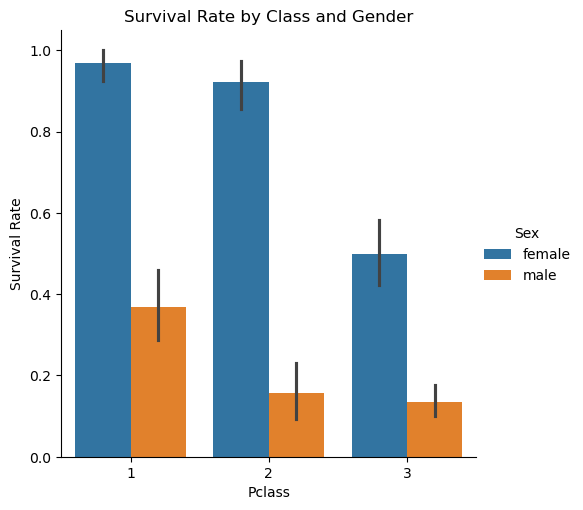

In [48]:
sns.catplot(x='Pclass', y='Survived', hue='Sex', data=df, kind='bar')
plt.title('Survival Rate by Class and Gender')
plt.ylabel('Survival Rate')
plt.show()

In [49]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
df.groupby('AgeGroup')['Survived'].mean() * 100

C:\Users\yadav\AppData\Local\Temp\ipykernel_29384\2562480033.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Survived'].mean() * 100


AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64

## Survival by Age Group
Children (0-12) had the highest survival rate (58.0%), consistent with
"women and children first" evacuation priority. Seniors (60+) had the
lowest (22.7%), possibly reflecting mobility challenges during evacuation.

In [50]:
#Logistic Regression for survival prediction
#data modeling
df_model = df.copy()
df_model['Sex'] = df_model['Sex'].map({'male' : 0, 'female' : 1})
df_model['Embarked'] = df_model['Embarked'].map({'S' : 0, 'C' : 1, 'Q' : 2})

In [51]:
features = ['Pclass', 'Sex', 'Age', 'SibSp','Parch', 'Fare', 'Embarked']
x = df_model[features]
y = df_model['Survived']

In [52]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [53]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [54]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy * 100: .2f}%")

Accuracy:  79.89%


In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



## Model Evaluation
The logistic regression model achieved 79.9% accuracy on the test set.
It performs slightly better at predicting deaths (85% recall) than
survivals (73% recall), likely because the training data has more
examples of non-survivors (61.6% of passengers died).

In [59]:
importance = pd.DataFrame({
    'Feature' : x.columns,
    'Coefficient' : model.coef_[0]
}).sort_values(by='Coefficient', ascending = False)

print(importance)

    Feature  Coefficient
1       Sex     2.581594
6  Embarked     0.222443
5      Fare     0.002863
2       Age    -0.031160
4     Parch    -0.100639
3     SibSp    -0.302984
0    Pclass    -0.958007


## Feature Importance
Sex was by far the strongest predictor (coefficient 2.58), confirming
the EDA finding that gender was the dominant survival factor. Pclass
had the second-strongest effect (-0.96), with lower survival odds for
lower ticket classes — again matching earlier findings.

## Key Findings

- Overall survival rate was 38.4% (549 died, 342 survived out of 891 passengers)
- **Gender was the strongest survival factor**: women survived at 74.2% vs. men at 18.9% — roughly 4x higher
- **Passenger class mattered significantly**: 1st class (63.0%) → 2nd class (47.3%) → 3rd class (24.2%)
- **Gender and class interact**: even 3rd class women (50.0%) outsurvived 1st class men (36.9%), showing gender was the dominant factor overall
- **Children had a survival advantage**: 58.0% survival rate vs. 22.7% for seniors
- A baseline logistic regression model achieved **79.9% accuracy**, with Sex and Pclass emerging as the two strongest predictors — confirming the EDA findings independently